In [13]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Female,Yes,39,No,Engineer,0.0,Low,2.0,Cat_6,A,Yes_Low,False
1,Male,No,28,Yes,Healthcare,1.0,Low,4.0,Cat_6,D,No_Low,False
2,Male,No,30,No,Healthcare,1.0,Low,4.0,Cat_2,A,No_Low,False
3,Male,Yes,62,Yes,Entertainment,1.0,Average,3.0,Cat_6,C,Yes_Average,False
4,Male,Yes,45,Yes,Artist,4.0,Average,4.0,Cat_6,B,Yes_Average,False


In [14]:
import numpy as np

Dataset_Train['Segmentation_Combined'] = np.where(
    Dataset_Train['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Train['Segmentation']
)

Dataset_Test['Segmentation_Combined'] = np.where(
    Dataset_Test['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Test['Segmentation']
)
Dataset_Train.head()
Dataset_Test.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier,Segmentation_Combined
0,Female,Yes,39,No,Engineer,0.0,Low,2.0,Cat_6,A,Yes_Low,False,ABC
1,Male,No,28,Yes,Healthcare,1.0,Low,4.0,Cat_6,D,No_Low,False,D
2,Male,No,30,No,Healthcare,1.0,Low,4.0,Cat_2,A,No_Low,False,ABC
3,Male,Yes,62,Yes,Entertainment,1.0,Average,3.0,Cat_6,C,Yes_Average,False,ABC
4,Male,Yes,45,Yes,Artist,4.0,Average,4.0,Cat_6,B,Yes_Average,False,ABC


In [15]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
#Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
#Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
#Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
#Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [16]:
print("Columns in Dataset_Train:", Dataset_Train.columns.tolist())
print("Columns in Dataset_Test:", Dataset_Test.columns.tolist())

Columns in Dataset_Train: ['Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation_Combined']
Columns in Dataset_Test: ['Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation_Combined']


In [17]:
#reducing the categories of profession variable
# Step 1: View the frequency of each profession
#profession_counts = Dataset_Train['Profession'].value_counts()
#print(profession_counts)

# Step 2: Define a threshold - professions with less than this count will be grouped as 'Other'
#threshold = 100  # You can adjust this threshold based on your dataset size

# Step 3: Create a list of professions to keep
#common_professions = profession_counts[profession_counts >= threshold].index.tolist()

# Step 4: Apply transformation to both training and test datasets
#def reduce_professions(df):
 #   df['Profession'] = df['Profession'].apply(lambda x: x if x in common_professions else 'Other')
  #  return df

# Apply to both datasets
#Dataset_Train = reduce_professions(Dataset_Train)
#Dataset_Test = reduce_professions(Dataset_Test)

# Optional: Re-check new distribution
#print("\n🔹 Profession distribution after reduction:")
#print(Dataset_Train['Profession'].value_counts())


In [18]:
# Bin 'Age' into categories
#age_bins = [0, 18, 35, 50, 65, 100]
#age_labels = ['<18', '18-35', '36-50', '51-65', '65+']
#Dataset_Train['Age_Binned'] = pd.cut(Dataset_Train['Age'], bins=age_bins, labels=age_labels, right=False)
#Dataset_Test['Age_Binned'] = pd.cut(Dataset_Test['Age'], bins=age_bins, labels=age_labels, right=False)


In [19]:
#Dataset_Train = Dataset_Train.drop('Age', axis=1)
#Dataset_Test = Dataset_Test.drop('Age', axis=1)

In [20]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

🔹 Class Counts:
Segmentation_Combined
ABC    6119
D      2406
Name: count, dtype: int64

🔹 Class Percentages:
Segmentation_Combined
ABC    71.78
D      28.22
Name: proportion, dtype: float64


C:\Users\Ashani Madushani\AppData\Local\Temp\ipykernel_9884\3910772525.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')


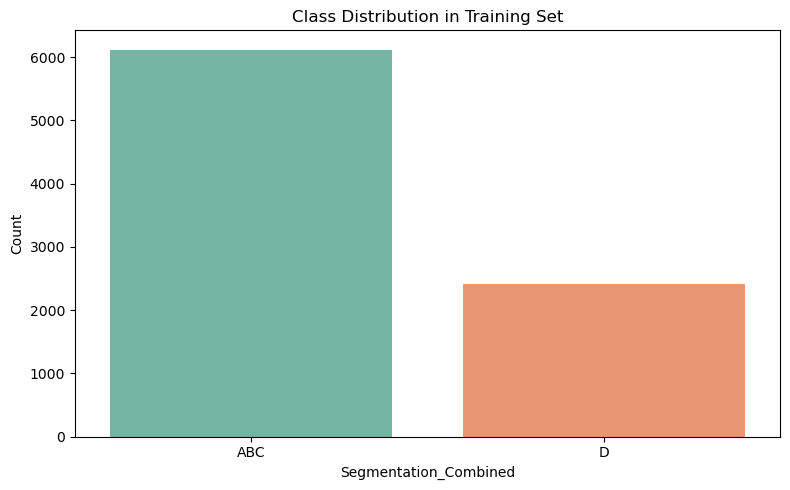

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of instances in each class
class_counts = Dataset_Train['Segmentation_Combined'].value_counts()
class_percentages = Dataset_Train['Segmentation_Combined'].value_counts(normalize=True) * 100

# Display results
print("🔹 Class Counts:")
print(class_counts)
print("\n🔹 Class Percentages:")
print(class_percentages.round(2))

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')
plt.title("Class Distribution in Training Set")
plt.xlabel("Segmentation_Combined")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Train Accuracy: 0.7843988269794722
✅ Test Accuracy: 0.7875234521575984

🔹 Classification Report (Test Data):
              precision    recall  f1-score   support

         ABC       0.81      0.92      0.86      1530
           D       0.69      0.45      0.55       602

    accuracy                           0.79      2132
   macro avg       0.75      0.69      0.70      2132
weighted avg       0.78      0.79      0.77      2132



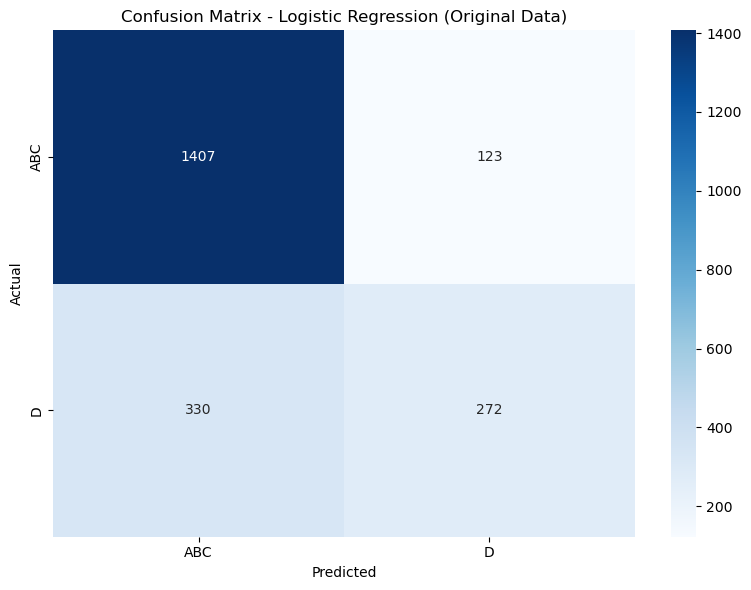

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (replace with your actual data loading)
# Dataset_Train = pd.read_csv('train.csv')
# Dataset_Test = pd.read_csv('test.csv')

# 1. Prepare features and target
X_train = Dataset_Train.drop(columns=['Segmentation_Combined'])
y_train = Dataset_Train['Segmentation_Combined']
X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']

# 2. Identify column types
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Preprocessor pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 4. Process data WITHOUT SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  # Use same encoder as training

# 6. Train Logistic Regression on original (imbalanced) data
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_processed, y_train_encoded)

# 7. Predictions
y_train_pred = le.inverse_transform(log_reg.predict(X_train_processed))
y_test_pred = le.inverse_transform(log_reg.predict(X_test_processed))

# 8. Evaluation
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=le.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Logistic Regression (Original Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Assuming your data is already loaded in Dataset_Train
X = Dataset_Train.drop(columns=['Segmentation_Combined'])
y = Dataset_Train['Segmentation_Combined']

# Split train/test if needed (optional)
# X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 1. Identify column types
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Preprocessor pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 3. Fit preprocessor and transform features
X_processed = preprocessor.fit_transform(X)

# 4. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_processed, y)

# 5. Optional: Check new class distribution
print("✅ Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Now you can use X_resampled and y_resampled to train your models


✅ Class distribution after SMOTE:
Segmentation_Combined
ABC    6119
D      6119
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Train Accuracy: 0.7440758293838863
✅ Test Accuracy : 0.7495309568480301

🔹 Classification Report (Test Data):
              precision    recall  f1-score   support

         ABC       0.86      0.77      0.82      1530
           D       0.54      0.69      0.61       602

    accuracy                           0.75      2132
   macro avg       0.70      0.73      0.71      2132
weighted avg       0.77      0.75      0.76      2132



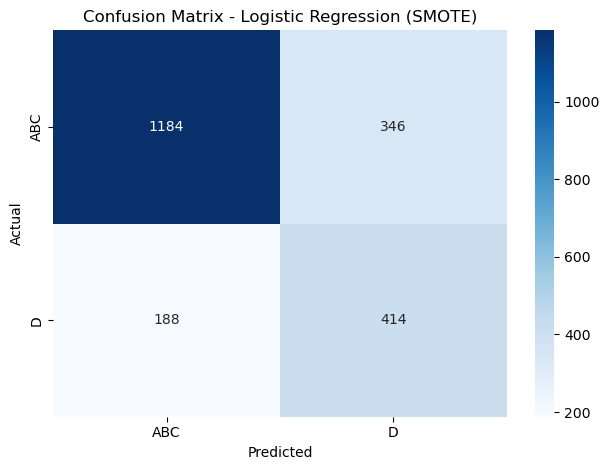

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Encode target labels for logistic regression (optional if already numeric)
le = LabelEncoder()
y_resampled_encoded = le.fit_transform(y_resampled)

# 2. Fit Logistic Regression model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_resampled, y_resampled_encoded)

# 3. Predictions on training (resampled) data
y_train_pred_encoded = log_reg.predict(X_resampled)
y_train_pred = le.inverse_transform(y_train_pred_encoded)

# 4. Process original test data
X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']
X_test_processed = preprocessor.transform(X_test)

# 5. Encode test labels and predict
y_test_pred_encoded = log_reg.predict(X_test_processed)
y_test_pred = le.inverse_transform(y_test_pred_encoded)

# 6. Accuracy scores
print("✅ Train Accuracy:", accuracy_score(y_resampled, y_train_pred))
print("✅ Test Accuracy :", accuracy_score(y_test, y_test_pred))

# 7. Classification report
print("\n🔹 Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# 8. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


4 segments